In [1]:
import random
from math import sqrt
import numpy
rng = numpy.random.default_rng()
def pifun(N, K):
    """
    la funzione calcola una stima di pigreco e dell'incertezza sulla stima in K iterazioni da N punti, inserisci N e K
    """
    #input(N);
    #input(K);
    pi = [];
    for k in range(K):
        counter = 1;
        inside = 0;

        while counter <= N:

            x = random.uniform(-1,1);
            y = random.uniform(-1,1);

            if x**2 + y**2 <= 1:

                inside += 1;

            counter +=1;
        piest = 4*inside/counter;

        pi.append(piest);
        

    ave = sum(pi)/len(pi);

    if K == 1:

        return ave;

    else:
    

        varsq = []
        for i in range(len(pi)):
            varsq.append((pi[i] - ave)**2) 
        std = sqrt(sum(varsq)/len(pi));

        return ave, std
if __name__ == '__main__' :
    N = int(input('give me N = '))
    K = int(input('give me K = '))
    if K == 1:
        ave = pifun(N, K)
        print(ave)
    else:
        [ave,std] = pifun(N,K)
        print(ave, std)

def pinpy(N, K):

    pi = [];
    for k in range(K):

        x = rng.uniform(low=-1, high=1, size=N)
        y = rng.uniform(low=-1, high=1, size=N)

        gianni = x*x + y*y;

        target = (gianni <=1);


        piest = 4*target.sum()/target.size;
        pi.append(piest);

    ave = sum(pi)/len(pi);

    varsq = [];
    for i in range(len(pi)):
        varsq.append((pi[i] - ave)**2); 
    std = sqrt(sum(varsq)/len(pi));

    return ave, std

give me N =  2
give me K =  2


2.6666666666666665 0.0


279.05121994018555


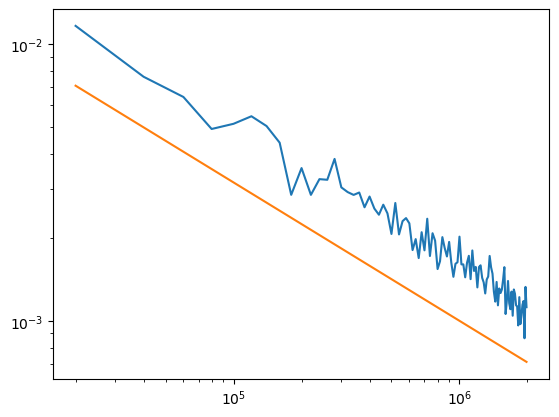

In [2]:
import matplotlib.pyplot as plt
import matplotlib.scale as mscale
import time
start = time.time()

pi = [];
scarto = [];
errore = [];
punti = [];
verifica = [];
for i in range(1,100):
    points=i*20000;
    punti.append(points);
    [ave,std] = pinpy(points,50);
    pi.append(ave);
    errore.append(std);
    scarto.append(ave-3.14159);
    verifica.append(1/sqrt(points))

end = time.time()
print(end - start)
fig, ax = plt.subplots()
ax.plot(punti,errore)
ax.plot(punti,verifica)
ax.set_xscale('log')
ax.set_yscale('log')


#plt.plot(punti, scarto)

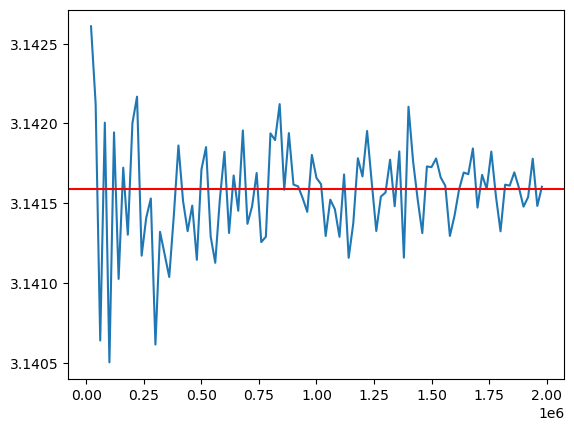

In [99]:
plt.plot(punti, pi)
plt.axhline(y=3.14159, color='r', linestyle='-')

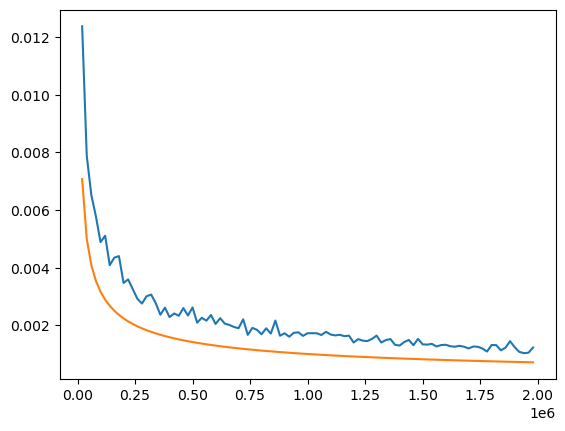

In [87]:
fig, ax = plt.subplots()
ax.plot(punti,errore)
ax.plot(punti,verifica)

In [74]:
import numpy 
rng = numpy.random.default_rng()
import time

start = time.time()
x = rng.uniform(low=-1, high=1, size=10000000)
y = rng.uniform(low=-1, high=1, size=10000000)

gianni = x*x + y*y

target = (gianni <=1)


pi = 4*target.sum()/x.size
end = time.time()
print(pi)
print(end-start)

3.1415608
0.20167851448059082


In [81]:
[ave, std]=pinpy(1000000, 100);

print(ave, std)


3.141645079999999 0.0016768880563710847


In [92]:
x = rng.uniform(low=-1, high=1, size=[2,3])
print(x)


[-0.58130453  0.55965934  0.81035993]


In [120]:
def pinpy2(N, K):

    pi = numpy.ndarray(K);
    x = rng.uniform(low=-1, high=1, size=(K,N))
    y = rng.uniform(low=-1, high=1, size=(K,N))
    gianni = x*x + y*y;
    for k in range(K):



        

        target = (gianni[k] <=1);


        piest = 4*target.sum()/target.size;
        pi[k]=piest;

    ave = sum(pi)/len(pi);

    varsq = [];
    for i in range(len(pi)):
        varsq.append((pi[i] - ave)**2); 
    std = sqrt(sum(varsq)/len(pi));

    return ave, std

In [123]:
start = time.time()

[ave,std] = pinpy(1000000,100);
print(ave, std)

end = time.time()

print(end - start)

3.1415960584039415 0.001535988359811747
33.55265283584595
